In [ ]:
import xarray as xr
import numpy as np
import functions
import glob as glob

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmcrameri as cm

import warnings
warnings.filterwarnings('ignore')

In [2]:
fbkdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedbacks/'

In [3]:
cldtype = 'ALL'
experiments = ['abrupt-0_5xCO2', 'abrupt-2xCO2', 'abrupt-4xCO2']
ds_list = []

interval=30
if interval == 30:
    tslicelist = [slice('1920-01-01', '1949-12-31'), slice('1950-01-01', '1979-12-31'),
                slice('1980-01-01', '2009-12-31'), slice('2010-01-01', '2039-12-31'),
                slice('2040-01-01', '2069-12-31')]
elif interval == 15:
    tslicelist = [slice('1920-01-01', '1934-12-31'), slice('1935-01-01', '1949-12-31'),
                slice('1950-01-01', '1964-12-31'), slice('1965-01-01', '1979-12-31'),
                slice('1980-01-01', '1994-12-31'), slice('1995-01-01', '2009-12-31'),
                slice('2010-01-01', '2024-12-31'), slice('2025-01-01', '2039-12-31'),
                slice('2040-01-01', '2054-12-31'), slice('2055-01-01', '2069-12-31')]
elif interval == 10:
    tslicelist = [slice('1920-01', '1929-12'), slice('1930-01-01', '1939-12-31'),
                slice('1940-01-01', '1949-12-31'), slice('1950-01-01', '1959-12-31'),
                slice('1960-01-01', '1969-12-31'), slice('1970-01-01', '1979-12-31'),
                slice('1980-01-01', '1989-12-31'), slice('1990-01-01', '1999-12-31'),
                slice('2000-01-01', '2009-12-31'), slice('2010-01-01', '2019-12-31'),
                slice('2020-01-01', '2029-12-31'), slice('2030-01-01', '2039-12-31'),
                slice('2040-01-01', '2049-12-31'), slice('2050-01-01', '2059-12-31'),
                slice('2060-01-01', '2069-12-31')]
N = int(150/interval)


for exp in experiments:

    fbk_files = glob.glob(fbkdir+'interval'+str(interval)+'/'+cldtype+'_'+exp+'_*')
    fbk_files.sort()
    fbk_ds = xr.open_mfdataset(fbk_files, combine='nested', concat_dim='period')
    ds_list.append(fbk_ds)

ds = xr.concat(ds_list, dim='co2_conc')
ds = ds.assign_coords({'period':np.arange(N)*interval})
ds = ds.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

In [4]:
datadir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'
landmask = xr.open_dataarray(datadir+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
landmask_feedback = landmask.interp_like(ds)
oceanmask_feedback = 1 - landmask_feedback

In [5]:
Arctic_limit = 60
period = 120
co2_conc = '4xCO2'

seasons = ['DJF','MAM','JJA','SON']
components = ['NETcld_amt', 'NETcld_tau','NETcld_tot','SWcld_amt', 'SWcld_tau', 'SWcld_tot']; component_names = ['Cloud\nAmount','Cloud\nOptical\nDepth', 'Total']

labels = [['(a)','(b)','(c)']]

# Choose subset of feedback variables, while selecting period of interest
var_list = []
for comp in components:
      var_list.append(ds[comp].sel(period=period)) 
feedbacks = xr.merge(var_list)

# Compute seasonal means and annual average
feedbacks_t_avg = [] # for feedbacks

feedbacks_seasons = feedbacks.groupby('time.season').mean('time')
for season in seasons:
    feedbacks_t_avg.append(feedbacks_seasons.sel(season=season).drop_vars('season'))
feedbacks_t_avg.append(feedbacks.mean('time'))

feedbacks_t_avg = xr.concat(feedbacks_t_avg,dim='time')
feedbacks_t_avg = feedbacks_t_avg.assign_coords({'time':seasons+['Annual']})
feedbacks_t_avg = feedbacks_t_avg.isel(time=slice(0,5))

# Compute Arctic spatial averages
feedbacks_Arctic = functions.computeWeightedMean(feedbacks_t_avg.sel(lat=slice(Arctic_limit, 90)))
# Compute Arctic spatial averages
feedbacks_Arctic_land = functions.computeWeightedMeanMasked(feedbacks_t_avg.sel(lat=slice(Arctic_limit, 90), lon=slice(0,300)), landmask_feedback.sel(lat=slice(Arctic_limit, 90), lon=slice(0,300)))
# Compute global spatial averages
feedbacks_global = functions.computeWeightedMean(feedbacks_t_avg)


time = 'Annual'
print('Arctic land ', time)
print(feedbacks_Arctic_land['NETcld_tot'].sel(co2_conc=co2_conc,time=time).values)
print(feedbacks_Arctic_land['SWcld_amt'].sel(co2_conc=co2_conc,time=time).values)

Arctic_land_area_factor = functions.computeWeightedSum(landmask_feedback.sel(lat=slice(Arctic_limit, 90), lon=slice(0,300)))
global_area_factor = functions.computeWeightedSum(landmask_feedback) + functions.computeWeightedSum(oceanmask_feedback)
area_weighting_factor = (Arctic_land_area_factor/global_area_factor).values

time = 'Annual'
print('Areaweighted')
print('Area weight', area_weighting_factor)
print(feedbacks_Arctic_land['NETcld_tot'].sel(co2_conc=co2_conc,time=time).values*area_weighting_factor)
print(feedbacks_Arctic_land['SWcld_amt'].sel(co2_conc=co2_conc,time=time).values*area_weighting_factor)

time = 'JJA'
area_weighting_factor *= 0.25
print('Areaweighted and timeweighted')
print('Area weight', area_weighting_factor)
print(feedbacks_Arctic_land['NETcld_tot'].sel(co2_conc=co2_conc,time=time).values*area_weighting_factor)
print(feedbacks_Arctic_land['SWcld_amt'].sel(co2_conc=co2_conc,time=time).values*area_weighting_factor)


print('Global')
print(feedbacks_global['NETcld_tot'].sel(co2_conc=co2_conc,time=time).values)


/tmp/ipykernel_2198544/1032606496.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  feedbacks = xr.merge(var_list)


Arctic land  Annual
1.7272301358911952
1.2949953501608606
Areaweighted
Area weight 0.030291100963235645
0.05231970243302342
0.03922683489864333
Areaweighted and timeweighted
Area weight 0.007572775240808911
0.04423314852893195
0.036922807636818815
Global
1.1588168032215773


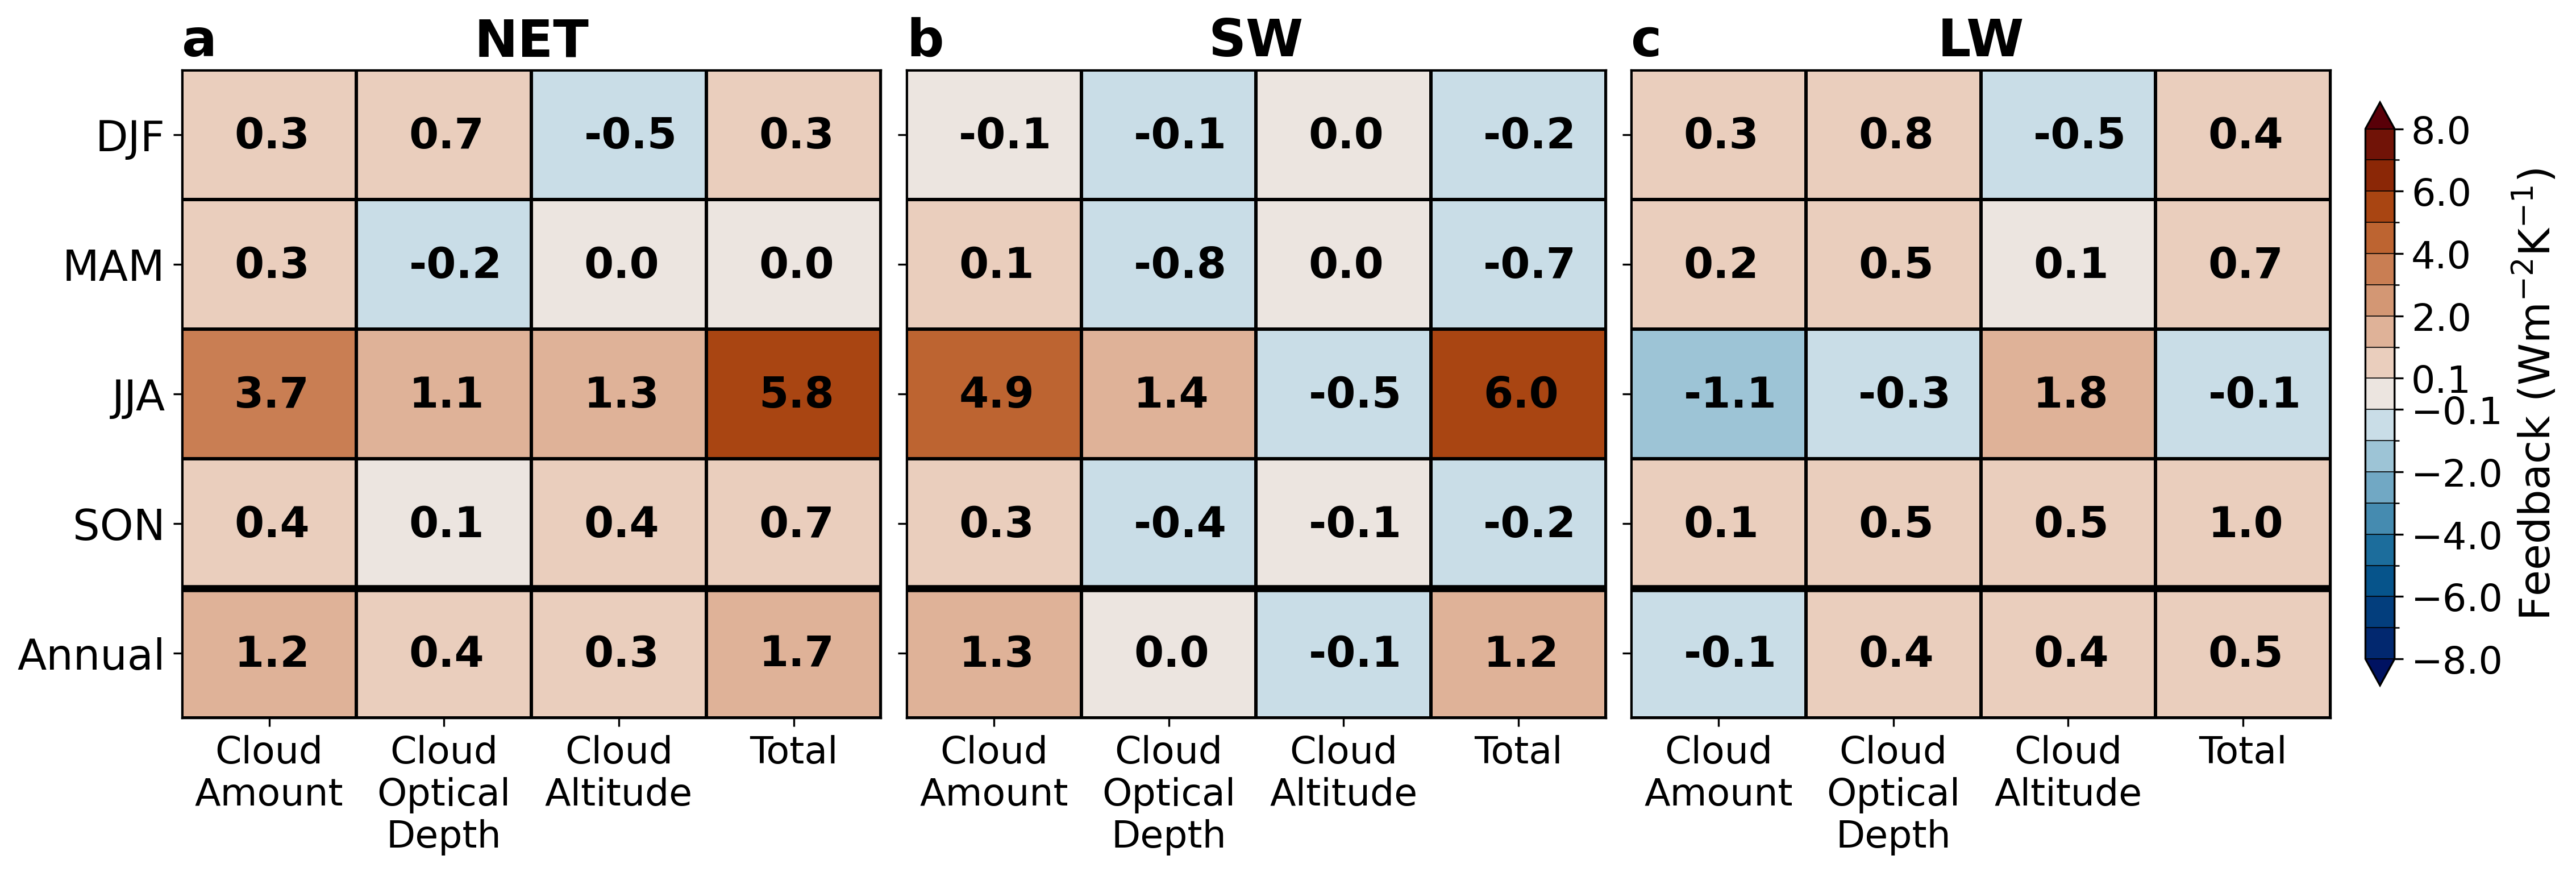

In [ ]:
Arctic_limit = 60
period = 120
co2_conc = '4xCO2'

seasons = ['DJF','MAM','JJA','SON']
component_names = ['Cloud\nAmount','Cloud\nOptical\nDepth', 'Cloud\nAltitude','Total']
feedbacks = ds.sel(period=period)

labels = [['a','b','c']]

# Compute seasonal means and annual average
feedbacks_t_avg = [] # for feedbacks

feedbacks_seasons = feedbacks.groupby('time.season').mean('time')
for season in seasons:
    feedbacks_t_avg.append(feedbacks_seasons.sel(season=season).drop_vars('season'))
    
feedbacks_t_avg.append(feedbacks.mean('time'))

feedbacks_t_avg = xr.concat(feedbacks_t_avg,dim='time')
feedbacks_t_avg = feedbacks_t_avg.assign_coords({'time':seasons+['Annual']})
feedbacks_t_avg = feedbacks_t_avg.isel(time=slice(0,5)) 

# Compute Arctic spatial averages
feedbacks_Arctic_land = functions.computeWeightedMeanMasked(feedbacks_t_avg.sel(lat=slice(Arctic_limit, 90), lon=slice(0,300)), landmask_feedback.sel(lat=slice(Arctic_limit, 90), lon=slice(0,300)))

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 5),dpi=300,constrained_layout=True, sharey=True)

# Define colorbar
uneven_levels = [-8,-7,-6,-5,-4,-3,-2,-1,-0.1,0.1,1,2,3,4,5,6, 7,8]
cmap_rb = cm.cm.vik
colors = cmap_rb(np.linspace(0, 1, len(uneven_levels)+1))
cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

# Plot spatially averaged feedbacks
for label, radiation in zip(['a', 'b', 'c'], ['NET', 'SW', 'LW']):

    components = [radiation +'cld_amt', radiation +'cld_tau', radiation +'cld_alt', radiation +'cld_tot']

    ax = axs[label]
    feedbacks_i = feedbacks_Arctic_land[components].sel(co2_conc=co2_conc).to_dataarray()
    X = np.arange(len(components))
    Y = np.arange(len(feedbacks_Arctic_land.time))
    map = ax.pcolormesh(X, Y, feedbacks_i.T, cmap=cmap,norm=norm,edgecolor='k',linewidths=1)
    ax.hlines(3.5,X[0]-0.5,X[-1]+0.5,color='k',linewidth=3)
    ax.set_xticks(np.arange(len(components)))
    ax.set_xticklabels(component_names,fontsize=16)
    ax.set_yticks(np.arange(len(feedbacks_Arctic_land.time)))
    ax.set_yticklabels(feedbacks_Arctic_land.time.values, fontsize=18)
    for x in X:
        for y in Y:
            avg_feedback = np.round(float(feedbacks_i[x][y]),1)
            if np.abs(avg_feedback) < 0.1:
                avg_feedback = np.abs(avg_feedback)
            ax.text(x-0.2, y+0.1, str(avg_feedback), fontsize=18, fontweight='bold')
    ax.invert_yaxis()
    ax.set_title(radiation, fontsize=22,fontweight='bold')


cb = fig.colorbar(map, ax=axs['c'], location='right', ticks=[-8,-6,-4,-2,-0.1, 0.1,2,4,6,8], drawedges=True,extend='both',shrink=0.9)

cb.set_label(label='Feedback (Wm$^{-2}$K$^{-1}$)',fontsize=18)
cb.ax.tick_params(labelsize=16, rotation=0)


# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=22,fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/png/FigA9.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/pdf/FigA9.pdf')


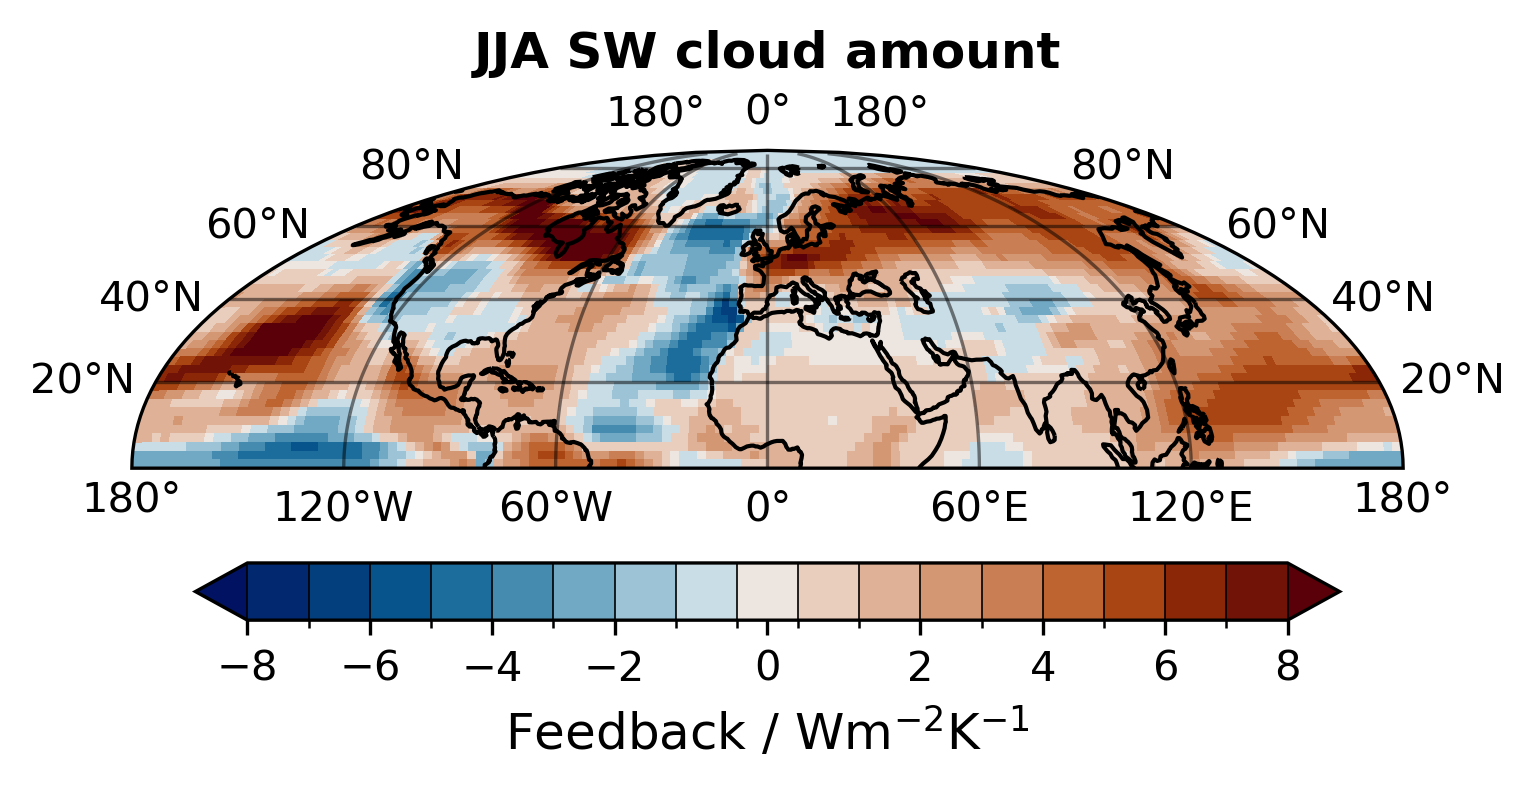

In [ ]:
period=120
feedbacks = ds.sel(period=period)
seasons = ['DJF','MAM','JJA','SON']

# Compute seasonal means and annual average
feedbacks_t_avg = [] # for feedbacks

feedbacks_seasons = feedbacks.groupby('time.season').mean('time')
for season in seasons:
    
    feedbacks_t_avg.append(feedbacks_seasons.sel(season=season).drop_vars('season'))
feedbacks_t_avg.append(feedbacks.mean('time'))


feedbacks_t_avg = xr.concat(feedbacks_t_avg,dim='time')
feedbacks_t_avg = feedbacks_t_avg.assign_coords({'time':seasons+['Annual']})
feedbacks_t_avg = feedbacks_t_avg.isel(time=slice(0,5)) # Drop DJF


# Define colorbar
uneven_levels = [-8,-7,-6,-5,-4,-3,-2,-1,-0.1,0.1,1,2,3,4,5,6, 7,8]
cmap_rb = cm.cm.vik
colors = cmap_rb(np.linspace(0, 1, len(uneven_levels)+1))
cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

fig = plt.figure(figsize=[5,3], dpi=300,constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())
map = feedbacks_t_avg['SWcld_amt'].sel(time='JJA', co2_conc='4xCO2', lat=slice(0,90)).plot(ax=ax, 
                                                                          transform=ccrs.PlateCarree(),
                                                                          cmap=cmap, norm=norm,
                                                                          add_colorbar=False)
ax.coastlines()
ax.gridlines(draw_labels=True,alpha=0.5,color='black',x_inline=False)
ax.set_title('JJA SW cloud amount',fontsize=12, fontweight='bold')
cb = fig.colorbar(map, ax=ax, location='bottom', orientation='horizontal',ticks=[-8,-6,-4,-2,0,2,4,6,8], drawedges=True,extend='both',shrink=0.9)

cb.set_label(label='Feedback / Wm$^{-2}$K$^{-1}$',fontsize=12)
cb.ax.tick_params(labelsize=10)
#feedbacks_t_avg['SWcld_amt'].sel(time='JJA', co2_conc='4xCO2').plot()